# K562 H3K27ac Enhancer Classification Pipeline
## From the Same Data, a Different Question

**Companion to the regression notebook — same data, different task framing.**

---

### Connection to the Regression Notebook

In the **regression notebook**, we asked:
> *How active is this enhancer?* (predicting continuous H3K27ac signal)

Now we ask a more fundamental question:
> ***Is this region an enhancer at all?*** (classifying peak vs. non-peak)

This is exactly what the lecture means by **"matching models to research goals"** —
the same data can support multiple questions, but each requires different:
- **Labels** (continuous signal → binary peak/non-peak)
- **Loss functions** (MSE → binary cross-entropy)
- **Metrics** (Pearson/Spearman → AUROC/AUPRC)
- **Data design** (only peaks → peaks + non-peak negatives)

### What stays the same?
- Raw data (ENCODE K562 H3K27ac ChIP-seq)
- Models (Nucleotide Transformer + CNN baseline)
- Chromosome-aware splits
- Staged fine-tuning strategy
- Saliency analysis

### Lecture Alignment

| Lecture Step | Section | Classification-Specific Changes |
|:---:|---|---|
| **0** | Biological question | Binary: enhancer or not? |
| **1** | Model selection | Same models, sigmoid output head |
| **2** | Fine-tuning strategy | Same staged approach |
| **3** | Data curation | **New: negative example generation** |
| **4–5** | Tokenization & preprocessing | Same (no signal normalization needed) |
| **6** | Experimental setup | **BCE loss, AUROC, AUPRC, F1** |
| **7** | Fine-tuning | Same staged approach |
| **8** | Evaluation | **ROC/PR curves, confusion matrix, per-chromosome AUROC** |


## The Biological Problem — Classification Framing

### Why classification?

In real genomics research, you often face this scenario: you have a genome with
~3 billion base pairs, and you want to identify which regions are **functional enhancers**.
This is inherently a **classification** problem — for any given stretch of DNA, is it
an enhancer or not?

### The regression notebook answered a *narrower* question

The regression task only looked at **known peak regions** and predicted *how active*
they are. But it never had to distinguish enhancers from the vast background of
non-functional DNA. That's the harder, more realistic problem.

### What makes this biologically challenging?

1. **Enhancers are sparse** — only ~2–5% of the genome has enhancer activity in any
   given cell type. In deployment, your classifier faces massive class imbalance.

2. **The "negative" class is heterogeneous** — non-enhancer DNA includes promoters,
   gene bodies, repetitive elements, heterochromatin, and random intergenic sequence.
   What you choose as "non-enhancer" examples profoundly shapes what the model learns.

3. **Sequence similarity** — enhancers share motifs (AP-1, GATA, ETS) that distinguish
   them from background DNA. The model must learn these motif grammars.

> *Lecture: "Negative sampling (matched for GC, mappability, distance)" is listed as
> a critical decision that "can dominate architecture choice."*


## Learning Objectives

After completing this notebook, you should be able to:

1. **Reframe** a regression task as classification using the same underlying data
2. **Generate negative examples** for genomic classification with awareness of potential biases
3. **Choose appropriate metrics** for binary classification (AUROC vs AUPRC vs accuracy)
4. **Visualize** ROC and precision-recall curves to assess model calibration
5. **Compare** classification to regression — when is each formulation more appropriate?

> *These build on the regression notebook. If you haven't completed that first, do so — it
> covers the foundational workflow (model selection, tokenization, staged fine-tuning)
> in more detail.*


In [27]:
# === INSTALLATION & DATA DOWNLOAD ===
# Same data as the regression notebook — skip if already downloaded
#!apt-get update -qq && apt-get install -y -qq bedtools samtools wget > /dev/null 2>&1
#!pip install -q torch transformers pyBigWig pandas numpy scikit-learn tqdm matplotlib seaborn captum pyfaidx

# Download ENCODE K562 H3K27ac data (same files as regression notebook)
import os
if not os.path.exists('K562_H3K27ac.bigWig'):
    !wget -qO K562_H3K27ac.bigWig "https://www.encodeproject.org/files/ENCFF465GBD/@@download/ENCFF465GBD.bigWig"
if not os.path.exists('K562_peaks.bed'):
    !wget -qO K562_peaks.bed.gz "https://www.encodeproject.org/files/ENCFF038DDS/@@download/ENCFF038DDS.bed.gz" && gunzip -f K562_peaks.bed.gz
if not os.path.exists('hg38.fa'):
    !wget -qO hg38.fa.gz "https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz" && gunzip -f hg38.fa.gz && samtools faidx hg38.fa
print('Data files ready.')


Data files ready.


In [28]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import pyBigWig
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             f1_score, accuracy_score, confusion_matrix,
                             roc_curve, precision_recall_curve)
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from captum.attr import IntegratedGradients
from pyfaidx import Fasta
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: cuda


In [ ]:
# ============================================================
# CONFIGURATION
# ============================================================
# QUICK_MODE = True  -> workshop demo (~10-15 min training)
# QUICK_MODE = False -> full dataset (~1-2 hours)
QUICK_MODE = False

MODEL_NAME = "InstaDeepAI/nucleotide-transformer-500m-human-ref"

if QUICK_MODE:
    MAX_PER_SPLIT = {'train': 5000, 'val': 1000, 'test': 2000}
    NUM_EPOCHS = 5
    BATCH_SIZE = 32
    print("QUICK_MODE: using data subset for faster training")
else:
    MAX_PER_SPLIT = {'train': None, 'val': None, 'test': None}
    NUM_EPOCHS = 10
    BATCH_SIZE = 32
    print("FULL MODE: using complete dataset")

NUM_UNFREEZE_LAYERS = 2
PATIENCE = 3
NT_MAX_LENGTH = 256


QUICK_MODE: using data subset for faster training


## Step 0 — Define the Biological Question

> *Lecture: "Before touching code, answer: What is the biological object?*
> *What is the prediction type? What is the resolution?"*

### Classification Task Definition

| Aspect | Regression Notebook | **This Notebook (Classification)** |
|--------|--------------------|------------------------------------|
| **Input** | 1 kb DNA sequence | 1 kb DNA sequence |
| **Output** | Continuous H3K27ac signal | **Binary: enhancer (1) or non-enhancer (0)** |
| **Resolution** | Locus-level, K562 | Locus-level, K562 |

**Formal definition:**

> Given a 1 kb DNA sequence from the human genome, predict whether
> it overlaps an H3K27ac peak in K562 cells (active enhancer) or not.

### When would you choose classification over regression?

- **Classification** when you need to **identify** enhancers from the whole genome
- **Regression** when you already know the enhancers and want to **rank** their activity
- In practice, classification is often the first step (find enhancers),
  regression is the second (quantify them)


In [30]:
# ============================================================
# Step 0: Load raw data (same as regression notebook)
# ============================================================

bw = pyBigWig.open('K562_H3K27ac.bigWig')

peaks = pd.read_csv('K562_peaks.bed', sep='\t', header=None, comment='#')
peaks.columns = ['chrom', 'start', 'end', 'name', 'score', 'strand',
                 'signal', 'pval', 'qval', 'peak']

# Center on peak summits (same as regression notebook)
peaks['summit'] = peaks['start'] + peaks['peak']
peaks['win_start'] = peaks['summit'] - 500
peaks['win_end'] = peaks['summit'] + 500

# Keep standard chromosomes, valid coordinates
valid_chroms = ['chr' + str(i) for i in range(1, 23)] + ['chrX']
peaks = peaks[peaks.chrom.isin(valid_chroms)]
peaks = peaks[peaks.win_start >= 0]

# Load reference genome
genome = Fasta('hg38.fa')

def get_seq(chrom, start, end):
    try:
        return str(genome[chrom][start:end]).upper()
    except Exception:
        return None

# Extract sequences for positive examples
peaks['sequence'] = peaks.apply(
    lambda r: get_seq(r.chrom, r.win_start, r.win_end), axis=1
)
peaks = peaks.dropna(subset=['sequence'])
peaks = peaks[peaks.sequence.apply(lambda s: s.count('N') / len(s) < 0.1)]
peaks = peaks.reset_index(drop=True)

print(f'Positive examples (H3K27ac peaks): {len(peaks):,}')
print(f'Chromosomes: {sorted(peaks.chrom.unique())}')


Positive examples (H3K27ac peaks): 52,315
Chromosomes: ['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr20', 'chr21', 'chr22', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chrX']


## Step 1 — Model Selection

> *Lecture: "Always compare to a reasonable baseline, not just other FMs."*

We use the **same two models** as the regression notebook, with one architectural
change: the output head produces a **single logit** (passed through sigmoid for
probability). This is the only structural difference.

| Component | Regression | Classification |
|-----------|-----------|----------------|
| **Backbone** | NT-500m (frozen/partial) | NT-500m (frozen/partial) |
| **Head output** | 1 neuron (raw value) | 1 neuron (logit → sigmoid) |
| **Baseline** | CNN (raw value) | CNN (logit → sigmoid) |
| **Loss** | MSE | BCEWithLogitsLoss |

> `BCEWithLogitsLoss` combines sigmoid + binary cross-entropy in one numerically
> stable operation. We output raw logits from the model, not probabilities.


In [31]:
# ============================================================
# Step 1: GFM Classifier (Nucleotide Transformer + classification head)
# ============================================================
# Same architecture as regression, but head outputs a single logit
# for binary classification. Sigmoid is applied by BCEWithLogitsLoss.

class GFMClassifier(nn.Module):
    """NT backbone + binary classification head.

    Output: raw logit (not probability). Use BCEWithLogitsLoss for training,
    apply sigmoid manually for inference/metrics.
    """
    def __init__(self, model_name, freeze_backbone=False):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False
        hidden = self.backbone.config.hidden_size
        self.head = nn.Sequential(
            nn.Linear(hidden, 128),
            nn.ReLU(),
            nn.Dropout(0.2),     # slightly more dropout for classification
            nn.Linear(128, 1),
        )

    def forward(self, input_ids, attention_mask):
        out = self.backbone(input_ids, attention_mask=attention_mask)
        cls_repr = out.last_hidden_state[:, 0]
        return self.head(cls_repr).squeeze(-1)  # raw logit


In [32]:
# ============================================================
# Step 1: CNN Baseline Classifier
# ============================================================
# Lecture: "Baseline: Small CNN trained from scratch on the same windows."

def one_hot_encode(seq, length=1000):
    """One-hot encode DNA to (4, length). N = all zeros."""
    mapping = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    encoded = np.zeros((4, length), dtype=np.float32)
    for i, base in enumerate(seq[:length]):
        if base in mapping:
            encoded[mapping[base], i] = 1.0
    return encoded

class CNNClassifier(nn.Module):
    """CNN baseline for binary classification on one-hot DNA."""
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(4, 64, kernel_size=15, padding=7),
            nn.ReLU(), nn.BatchNorm1d(64), nn.MaxPool1d(4),
            nn.Conv1d(64, 128, kernel_size=7, padding=3),
            nn.ReLU(), nn.BatchNorm1d(128), nn.MaxPool1d(4),
            nn.Conv1d(128, 64, kernel_size=5, padding=2),
            nn.ReLU(), nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Sequential(
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.head(self.conv(x).squeeze(-1)).squeeze(-1)  # raw logit


## Step 2 — Fine-Tuning Strategy

Same staged approach as the regression notebook:

1. **Stage 1 — Frozen backbone:** train classification head only
2. **Stage 2 — Partial unfreeze:** top 2 layers + differential LR

> *Lecture: "Many papers overfit by fine-tuning huge backbones on tiny datasets."*
> With ~50k balanced examples, partial fine-tuning is appropriate (1k–50k range).


## Step 3 — Data Curation: Generating Negative Examples

> *Lecture: "Negative sampling (matched for GC, mappability, distance)" is a critical decision.*

### This is the key difference from the regression notebook

For **regression**, we only needed peak regions (all positives, varying signal).
For **classification**, we need **two classes**:

| Class | Source | Definition |
|-------|--------|-----------|
| **Positive (1)** | H3K27ac peaks | 1 kb centered on peak summit |
| **Negative (0)** | Random genomic regions | 1 kb windows that do NOT overlap any peak |

### Why is negative selection critical?

The choice of negatives determines **what the model actually learns:**

- **Random genomic negatives** → model may learn to distinguish repetitive/low-complexity
  DNA from genic regions, rather than learning enhancer-specific motifs
- **GC-matched negatives** → forces the model to look beyond base composition
- **Promoter-matched negatives** → forces the model to distinguish enhancers from
  other regulatory elements (harder, more biologically meaningful)

For this workshop, we use **random non-peak genomic regions** and discuss the
implications. More sophisticated negative sampling is an important extension.

### Class balance

We generate **equal numbers** of positives and negatives (1:1 ratio) per chromosome.
In reality, enhancers cover ~2–5% of the genome, so a deployed classifier would face
severe imbalance. We discuss this when choosing metrics (Step 6).


In [33]:
# ============================================================
# Step 3: Generate negative examples (non-peak genomic regions)
# ============================================================
# This is the critical step that doesn't exist in the regression notebook.
# We sample random 1kb windows that do NOT overlap any H3K27ac peak.

# Load chromosome sizes from FASTA index
chrom_sizes = {}
with open('hg38.fa.fai') as f:
    for line in f:
        parts = line.strip().split('\t')
        if parts[0] in valid_chroms:
            chrom_sizes[parts[0]] = int(parts[1])

# Build a fast lookup for peak regions using 500bp genomic bins.
# If a bin overlaps any peak, we mark it as "occupied".
BIN_SIZE = 500
occupied_bins = set()
for _, row in peaks.iterrows():
    for b in range(row.win_start // BIN_SIZE, row.win_end // BIN_SIZE + 1):
        occupied_bins.add((row.chrom, b))

def overlaps_peak(chrom, start, end):
    """Fast check: does [start, end) overlap any peak? Uses binned lookup."""
    for b in range(start // BIN_SIZE, end // BIN_SIZE + 1):
        if (chrom, b) in occupied_bins:
            return True
    return False

# Generate negatives: match the number of positives per chromosome
np.random.seed(42)
pos_per_chrom = peaks.chrom.value_counts().to_dict()
negatives = []

print('Generating negative examples per chromosome...')
for chrom, n_pos in sorted(pos_per_chrom.items()):
    size = chrom_sizes.get(chrom, 0)
    if size < 2000:
        continue
    found = 0
    attempts = 0
    while found < n_pos and attempts < n_pos * 30:
        center = np.random.randint(500, size - 500)
        start, end = center - 500, center + 500
        if not overlaps_peak(chrom, start, end):
            negatives.append({'chrom': chrom, 'win_start': start, 'win_end': end})
            found += 1
        attempts += 1
    print(f'  {chrom}: {found:,} negatives (from {n_pos:,} positives)')

neg_df = pd.DataFrame(negatives)
print(f'\nTotal negatives generated: {len(neg_df):,}')


Generating negative examples per chromosome...
  chr1: 5,221 negatives (from 5,221 positives)
  chr10: 2,304 negatives (from 2,304 positives)
  chr11: 2,885 negatives (from 2,885 positives)
  chr12: 2,668 negatives (from 2,668 positives)
  chr13: 884 negatives (from 884 positives)
  chr14: 1,633 negatives (from 1,633 positives)
  chr15: 1,659 negatives (from 1,659 positives)
  chr16: 2,060 negatives (from 2,060 positives)
  chr17: 2,936 negatives (from 2,936 positives)
  chr18: 802 negatives (from 802 positives)
  chr19: 3,324 negatives (from 3,324 positives)
  chr2: 3,597 negatives (from 3,597 positives)
  chr20: 1,549 negatives (from 1,549 positives)
  chr21: 573 negatives (from 573 positives)
  chr22: 1,250 negatives (from 1,250 positives)
  chr3: 3,222 negatives (from 3,222 positives)
  chr4: 1,820 negatives (from 1,820 positives)
  chr5: 2,274 negatives (from 2,274 positives)
  chr6: 3,179 negatives (from 3,179 positives)
  chr7: 2,571 negatives (from 2,571 positives)
  chr8: 2,06

In [34]:
# ============================================================
# Step 3: Extract sequences for negatives and combine with positives
# ============================================================

print('Extracting sequences for negative regions...')
neg_df['sequence'] = neg_df.apply(
    lambda r: get_seq(r.chrom, r.win_start, r.win_end), axis=1
)
neg_df = neg_df.dropna(subset=['sequence'])
neg_df = neg_df[neg_df.sequence.apply(lambda s: s.count('N') / len(s) < 0.1)]
neg_df['label'] = 0

# Prepare positive dataframe
pos_df = peaks[['chrom', 'win_start', 'win_end', 'sequence']].copy()
pos_df['label'] = 1

# Combine
all_data = pd.concat([pos_df, neg_df], ignore_index=True)
print(f'Combined dataset: {len(all_data):,} examples')
print(f'  Positives: {(all_data.label == 1).sum():,}')
print(f'  Negatives: {(all_data.label == 0).sum():,}')
print(f'  Balance: {all_data.label.mean():.2%} positive')

# ============================================================
# Chromosome-aware splits (matching lecture exactly)
# ============================================================
# Lecture: Train chr1-16, Val chr17-18, Test chr19-22+X
train_chroms = ['chr' + str(i) for i in range(1, 17)]
val_chroms   = ['chr17', 'chr18']
test_chroms  = ['chr' + str(i) for i in range(19, 23)] + ['chrX']

train_df = all_data[all_data.chrom.isin(train_chroms)].copy()
val_df   = all_data[all_data.chrom.isin(val_chroms)].copy()
test_df  = all_data[all_data.chrom.isin(test_chroms)].copy()

print(f'\nFull splits:')
for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    pos = (df.label == 1).sum()
    neg = (df.label == 0).sum()
    print(f'  {name}: {len(df):,} (pos={pos:,}, neg={neg:,}, balance={df.label.mean():.2%})')

# QUICK_MODE subsetting (stratified to preserve class balance)
if QUICK_MODE:
    for name, max_n in MAX_PER_SPLIT.items():
        if max_n is None:
            continue
        df = {'train': train_df, 'val': val_df, 'test': test_df}[name]
        if len(df) > max_n:
            # Stratified sampling: equal positives and negatives
            n_each = max_n // 2
            pos_sample = df[df.label == 1].sample(n=min(n_each, (df.label==1).sum()), random_state=42)
            neg_sample = df[df.label == 0].sample(n=min(n_each, (df.label==0).sum()), random_state=42)
            sampled = pd.concat([pos_sample, neg_sample]).sample(frac=1, random_state=42)
            if name == 'train': train_df = sampled
            elif name == 'val': val_df = sampled
            else: test_df = sampled

    print(f'\nAfter QUICK_MODE subsetting:')
    for nm, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
        print(f'  {nm}: {len(df):,} (balance={df.label.mean():.2%})')


Extracting sequences for negative regions...
Combined dataset: 102,500 examples
  Positives: 52,315
  Negatives: 50,185
  Balance: 51.04% positive

Full splits:
  Train: 78,460 (pos=40,075, neg=38,385, balance=51.08%)
  Val: 7,460 (pos=3,738, neg=3,722, balance=50.11%)
  Test: 16,580 (pos=8,502, neg=8,078, balance=51.28%)

After QUICK_MODE subsetting:
  Train: 5,000 (balance=50.00%)
  Val: 1,000 (balance=50.00%)
  Test: 2,000 (balance=50.00%)


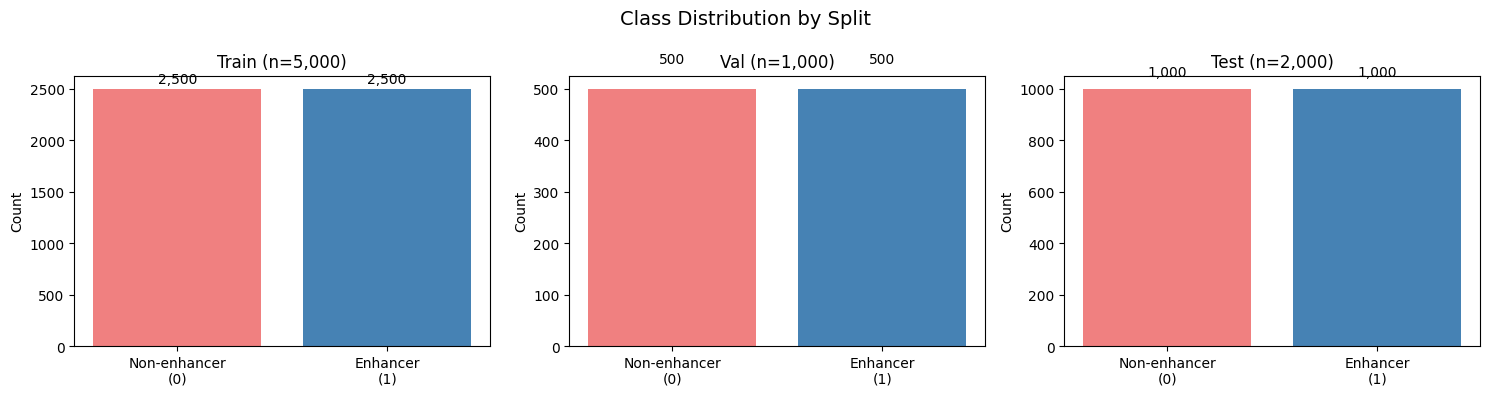

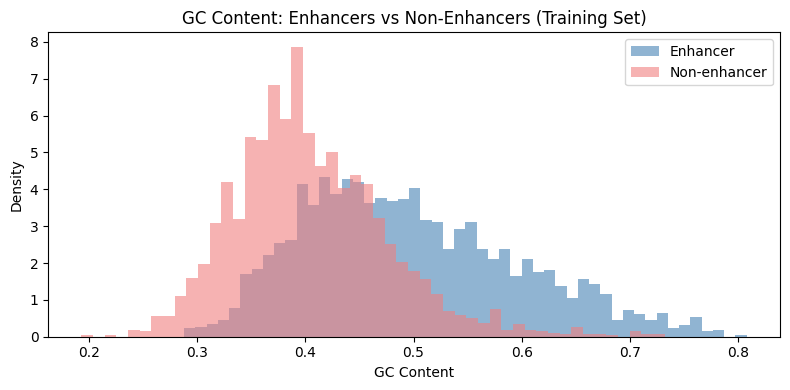

> Note: If GC distributions differ strongly, the model might learn GC content
> rather than enhancer-specific motifs. GC-matched negatives would control for this.
> This is a known limitation of random negative sampling.


In [35]:
# ============================================================
# Step 3: Visualize the classification dataset
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, df) in zip(axes, [('Train', train_df), ('Val', val_df), ('Test', test_df)]):
    counts = df.label.value_counts().sort_index()
    bars = ax.bar(['Non-enhancer\n(0)', 'Enhancer\n(1)'], counts.values,
                  color=['lightcoral', 'steelblue'])
    ax.set_title(f'{name} (n={len(df):,})')
    ax.set_ylabel('Count')
    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{count:,}', ha='center', fontsize=10)

plt.suptitle('Class Distribution by Split', fontsize=14)
plt.tight_layout()
plt.show()

# GC content comparison (are negatives different from positives?)
fig, ax = plt.subplots(figsize=(8, 4))
for label, color, name in [(1, 'steelblue', 'Enhancer'), (0, 'lightcoral', 'Non-enhancer')]:
    subset = train_df[train_df.label == label]
    gc = subset.sequence.apply(lambda s: (s.count('G') + s.count('C')) / len(s))
    ax.hist(gc, bins=50, alpha=0.6, color=color, label=name, density=True)
ax.set_xlabel('GC Content')
ax.set_ylabel('Density')
ax.set_title('GC Content: Enhancers vs Non-Enhancers (Training Set)')
ax.legend()
plt.tight_layout()
plt.show()

print('> Note: If GC distributions differ strongly, the model might learn GC content')
print('> rather than enhancer-specific motifs. GC-matched negatives would control for this.')
print('> This is a known limitation of random negative sampling.')


## Steps 4–5 — Tokenization & Preprocessing

Same tokenization as the regression notebook:
- **NT:** native learned tokenizer
- **CNN:** one-hot encoding (A, C, G, T → 4 channels)

### Key preprocessing difference from regression

| Aspect | Regression | Classification |
|--------|-----------|----------------|
| **Labels** | log1p(mean_signal) — continuous | 0 or 1 — binary |
| **Signal normalization** | Required (log-transform) | **Not needed** (labels are already 0/1) |
| **Class balance** | N/A | Must be maintained in batches |


In [36]:
# ============================================================
# Steps 4-5: Dataset classes for classification
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'NT tokenizer vocabulary size: {tokenizer.vocab_size:,}')

class NTClassificationDataset(Dataset):
    """Dataset for NT: tokenized input + binary label."""
    def __init__(self, df):
        self.seqs = df.sequence.values
        self.labels = df.label.values.astype(np.float32)

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        enc = tokenizer(self.seqs[idx], return_tensors='pt',
                        truncation=True, padding='max_length', max_length=NT_MAX_LENGTH)
        return {
            'input_ids': enc.input_ids.squeeze(0),
            'attention_mask': enc.attention_mask.squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float32),
        }

class CNNClassificationDataset(Dataset):
    """Dataset for CNN: one-hot encoded input + binary label."""
    def __init__(self, df, seq_len=1000):
        self.seqs = df.sequence.values
        self.labels = df.label.values.astype(np.float32)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        return {
            'sequence': torch.tensor(one_hot_encode(self.seqs[idx], self.seq_len)),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float32),
        }

# Create DataLoaders
train_loader_nt = DataLoader(NTClassificationDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader_nt   = DataLoader(NTClassificationDataset(val_df),   batch_size=BATCH_SIZE)
test_loader_nt  = DataLoader(NTClassificationDataset(test_df),  batch_size=BATCH_SIZE)

train_loader_cnn = DataLoader(CNNClassificationDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader_cnn   = DataLoader(CNNClassificationDataset(val_df),   batch_size=BATCH_SIZE)
test_loader_cnn  = DataLoader(CNNClassificationDataset(test_df),  batch_size=BATCH_SIZE)

print(f'NT  — Train: {len(train_loader_nt)} batches | Val: {len(val_loader_nt)} | Test: {len(test_loader_nt)}')
print(f'CNN — Train: {len(train_loader_cnn)} batches | Val: {len(val_loader_cnn)} | Test: {len(test_loader_cnn)}')


NT tokenizer vocabulary size: 4,107
NT  — Train: 157 batches | Val: 32 | Test: 63
CNN — Train: 157 batches | Val: 32 | Test: 63


## Step 6 — Experimental Setup: Classification Metrics

> *Lecture: "AUPRC more informative when rare" and "Avoid accuracy for heavily imbalanced tasks"*

### Why not just use accuracy?

With balanced classes (50/50), accuracy is reasonable. But consider deployment:
enhancers are ~2–5% of the genome. A model that predicts "non-enhancer" for everything
would achieve **95–98% accuracy** while being completely useless.

### Our metric choices

| Metric | What it measures | Why we use it |
|--------|-----------------|---------------|
| **AUROC** | Discrimination ability across all thresholds | Standard for balanced binary tasks; 0.5 = random |
| **AUPRC** | Precision-recall trade-off | More informative for rare positives; baseline = class proportion |
| **F1 Score** | Harmonic mean of precision and recall | Single-number summary at default threshold (0.5) |
| **Accuracy** | Fraction correct | Included for completeness, but interpret carefully |

### Loss function

**BCEWithLogitsLoss** — binary cross-entropy with built-in sigmoid.
The model outputs raw logits; the loss applies sigmoid internally for numerical stability.

> *Lecture: "Make decisions explicit."*

### Early stopping

We use **validation AUROC** for early stopping — it's threshold-independent and
measures overall ranking quality, which is what we care about in this task.


In [37]:
# ============================================================
# Step 6: Training and evaluation utilities for classification
# ============================================================

def train_one_epoch(model, loader, optimizer, loss_fn, model_type='gfm'):
    """Train one epoch. Returns average loss."""
    model.train()
    total_loss = 0
    for batch in tqdm(loader, desc='Training', leave=False):
        optimizer.zero_grad()
        labels = batch['labels'].to(device)
        if model_type == 'gfm':
            logits = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
        else:
            logits = model(batch['sequence'].to(device))
        loss = loss_fn(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, model_type='gfm'):
    """Evaluate classifier. Returns dict with AUROC, AUPRC, F1, accuracy."""
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            if model_type == 'gfm':
                logits = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
            else:
                logits = model(batch['sequence'].to(device))
            all_logits.append(logits.cpu())
            all_labels.append(batch['labels'])

    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    probs = 1 / (1 + np.exp(-logits))      # sigmoid
    preds = (probs >= 0.5).astype(int)

    return {
        'auroc': float(roc_auc_score(labels, probs)),
        'auprc': float(average_precision_score(labels, probs)),
        'f1':    float(f1_score(labels, preds)),
        'accuracy': float(accuracy_score(labels, preds)),
    }


def get_predictions(model, loader, model_type='gfm'):
    """Get raw predictions for plotting ROC/PR curves."""
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            if model_type == 'gfm':
                logits = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
            else:
                logits = model(batch['sequence'].to(device))
            all_logits.append(logits.cpu())
            all_labels.append(batch['labels'])
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    probs = 1 / (1 + np.exp(-logits))
    return probs, labels


def train_model(model, train_ldr, val_ldr, optimizer, loss_fn,
                model_type='gfm', num_epochs=NUM_EPOCHS, patience=PATIENCE,
                save_path='best_model.pt'):
    """Training loop with early stopping on validation AUROC."""
    best_val_auroc = -1
    patience_counter = 0
    history = {'train_loss': [], 'val_auroc': [], 'val_auprc': []}

    for epoch in range(num_epochs):
        loss = train_one_epoch(model, train_ldr, optimizer, loss_fn, model_type)
        val = evaluate(model, val_ldr, model_type)

        history['train_loss'].append(loss)
        history['val_auroc'].append(val['auroc'])
        history['val_auprc'].append(val['auprc'])

        print(f'  Epoch {epoch+1}/{num_epochs} — Loss: {loss:.4f} | '
              f'Val AUROC: {val["auroc"]:.4f} | Val AUPRC: {val["auprc"]:.4f}')

        if val['auroc'] > best_val_auroc:
            best_val_auroc = val['auroc']
            torch.save(model.state_dict(), save_path)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'  Early stopping at epoch {epoch+1}')
                break

    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
    return model, history


## Step 7 — Fine-Tuning

### Stage 1: Frozen Backbone

> *Lecture: "Freeze backbone, train prediction head → diagnostic baseline"*

Same strategy as regression: freeze all 480M backbone parameters,
train only the ~16k classification head parameters.


In [38]:
# ============================================================
# Step 7, Stage 1: Frozen backbone — train classification head only
# ============================================================

print('=' * 60)
print('STAGE 1: Frozen Backbone')
print('=' * 60)

gfm_model = GFMClassifier(MODEL_NAME, freeze_backbone=True).to(device)

trainable = sum(p.numel() for p in gfm_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in gfm_model.parameters())
print(f'Trainable: {trainable:,} / {total_params:,} ({100*trainable/total_params:.2f}%)')

optimizer_s1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, gfm_model.parameters()),
    lr=1e-3, weight_decay=0.01
)
loss_fn = nn.BCEWithLogitsLoss()

gfm_model, history_s1 = train_model(
    gfm_model, train_loader_nt, val_loader_nt, optimizer_s1, loss_fn,
    model_type='gfm', save_path='best_cls_frozen.pt'
)

frozen_test = evaluate(gfm_model, test_loader_nt, model_type='gfm')
print(f'\nStage 1 (Frozen) Test Results:')
for k, v in frozen_test.items():
    print(f'  {k}: {v:.4f}')


STAGE 1: Frozen Backbone


Some weights of EsmModel were not initialized from the model checkpoint at InstaDeepAI/nucleotide-transformer-500m-human-ref and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable: 164,097 / 480,602,338 (0.03%)


  Epoch 1/5 — Loss: 0.5841 | Val AUROC: 0.8086 | Val AUPRC: 0.8244


  Epoch 2/5 — Loss: 0.5560 | Val AUROC: 0.8128 | Val AUPRC: 0.8294


  Epoch 3/5 — Loss: 0.5350 | Val AUROC: 0.8153 | Val AUPRC: 0.8328


  Epoch 4/5 — Loss: 0.5345 | Val AUROC: 0.8174 | Val AUPRC: 0.8351


  Epoch 5/5 — Loss: 0.5166 | Val AUROC: 0.8191 | Val AUPRC: 0.8372

Stage 1 (Frozen) Test Results:
  auroc: 0.8233
  auprc: 0.8225
  f1: 0.7153
  accuracy: 0.7310


### Stage 2: Partial Unfreeze

> *Lecture: "Unfreeze top N layers (e.g., 2–4), train with low LR on backbone"*

Differential learning rates: head at 1e-3, unfrozen backbone layers at 1e-5.


In [39]:
# ============================================================
# Step 7, Stage 2: Unfreeze top 2 transformer layers
# ============================================================

print('=' * 60)
print(f'STAGE 2: Unfreezing Top {NUM_UNFREEZE_LAYERS} Layers')
print('=' * 60)

gfm_model.load_state_dict(torch.load('best_cls_frozen.pt', map_location=device, weights_only=True))

encoder_layers = gfm_model.backbone.encoder.layer
print(f'Backbone: {len(encoder_layers)} layers; unfreezing top {NUM_UNFREEZE_LAYERS}')

for layer in encoder_layers[-NUM_UNFREEZE_LAYERS:]:
    for p in layer.parameters():
        p.requires_grad = True

trainable = sum(p.numel() for p in gfm_model.parameters() if p.requires_grad)
print(f'Trainable: {trainable:,} / {total_params:,} ({100*trainable/total_params:.2f}%)')

unfrozen_params = []
for layer in encoder_layers[-NUM_UNFREEZE_LAYERS:]:
    unfrozen_params.extend(layer.parameters())

optimizer_s2 = torch.optim.AdamW([
    {'params': gfm_model.head.parameters(), 'lr': 1e-3},
    {'params': unfrozen_params, 'lr': 1e-5},
], weight_decay=0.01)

gfm_model, history_s2 = train_model(
    gfm_model, train_loader_nt, val_loader_nt, optimizer_s2, loss_fn,
    model_type='gfm', save_path='best_cls_partial.pt'
)

partial_test = evaluate(gfm_model, test_loader_nt, model_type='gfm')
print(f'\nStage 2 (Partial FT) Test Results:')
for k, v in partial_test.items():
    print(f'  {k}: {v:.4f}')


STAGE 2: Unfreezing Top 2 Layers
Backbone: 24 layers; unfreezing top 2
Trainable: 39,518,977 / 480,602,338 (8.22%)


  Epoch 1/5 — Loss: 0.5228 | Val AUROC: 0.8219 | Val AUPRC: 0.8395


  Epoch 2/5 — Loss: 0.5101 | Val AUROC: 0.8211 | Val AUPRC: 0.8383


  Epoch 3/5 — Loss: 0.5000 | Val AUROC: 0.8207 | Val AUPRC: 0.8385


  Epoch 4/5 — Loss: 0.4909 | Val AUROC: 0.8216 | Val AUPRC: 0.8392
  Early stopping at epoch 4

Stage 2 (Partial FT) Test Results:
  auroc: 0.8253
  auprc: 0.8258
  f1: 0.7530
  accuracy: 0.7225


### CNN Baseline

> *Lecture: "Always compare to a reasonable baseline, not just other FMs."*

How well can a simple CNN — with no pre-training — classify enhancers?


In [40]:
# ============================================================
# Step 7: CNN Baseline
# ============================================================

print('=' * 60)
print('CNN BASELINE: Training from scratch')
print('=' * 60)

cnn_model = CNNClassifier().to(device)
print(f'CNN parameters: {sum(p.numel() for p in cnn_model.parameters()):,}')

optimizer_cnn = torch.optim.AdamW(cnn_model.parameters(), lr=1e-3, weight_decay=0.01)

cnn_model, history_cnn = train_model(
    cnn_model, train_loader_cnn, val_loader_cnn, optimizer_cnn, loss_fn,
    model_type='cnn', save_path='best_cls_cnn.pt'
)

cnn_test = evaluate(cnn_model, test_loader_cnn, model_type='cnn')
print(f'\nCNN Baseline Test Results:')
for k, v in cnn_test.items():
    print(f'  {k}: {v:.4f}')


CNN BASELINE: Training from scratch
CNN parameters: 104,897


  Epoch 1/5 — Loss: 0.5777 | Val AUROC: 0.7953 | Val AUPRC: 0.8180


  Epoch 2/5 — Loss: 0.5427 | Val AUROC: 0.8251 | Val AUPRC: 0.8393


  Epoch 3/5 — Loss: 0.5115 | Val AUROC: 0.8268 | Val AUPRC: 0.8394


  Epoch 4/5 — Loss: 0.4750 | Val AUROC: 0.8235 | Val AUPRC: 0.8343


  Epoch 5/5 — Loss: 0.4368 | Val AUROC: 0.8170 | Val AUPRC: 0.8253

CNN Baseline Test Results:
  auroc: 0.8205
  auprc: 0.8267
  f1: 0.7173
  accuracy: 0.7320


## Step 8 — Evaluation & Interpretation

> *Lecture: "Beyond scalar performance... Attribution maps, motif recovery, per-chromosome generalization."*

### Evaluation plan

1. **Model comparison table** — all metrics side by side
2. **ROC and Precision-Recall curves** — visual assessment
3. **Confusion matrices** — where do models make mistakes?
4. **Per-chromosome AUROC** — is performance uniform?
5. **Saliency maps** — what sequence features drive "enhancer" predictions?


In [41]:
# ============================================================
# Step 8: Model comparison
# ============================================================

results_table = pd.DataFrame({
    'GFM Frozen': frozen_test,
    'GFM Partial FT': partial_test,
    'CNN Baseline': cnn_test,
}).T

print('=' * 60)
print('MODEL COMPARISON (Test Set)')
print('=' * 60)
print(results_table.to_string(float_format='{:.4f}'.format))


MODEL COMPARISON (Test Set)
                auroc  auprc     f1  accuracy
GFM Frozen     0.8233 0.8225 0.7153    0.7310
GFM Partial FT 0.8253 0.8258 0.7530    0.7225
CNN Baseline   0.8205 0.8267 0.7173    0.7320


Some weights of EsmModel were not initialized from the model checkpoint at InstaDeepAI/nucleotide-transformer-500m-human-ref and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


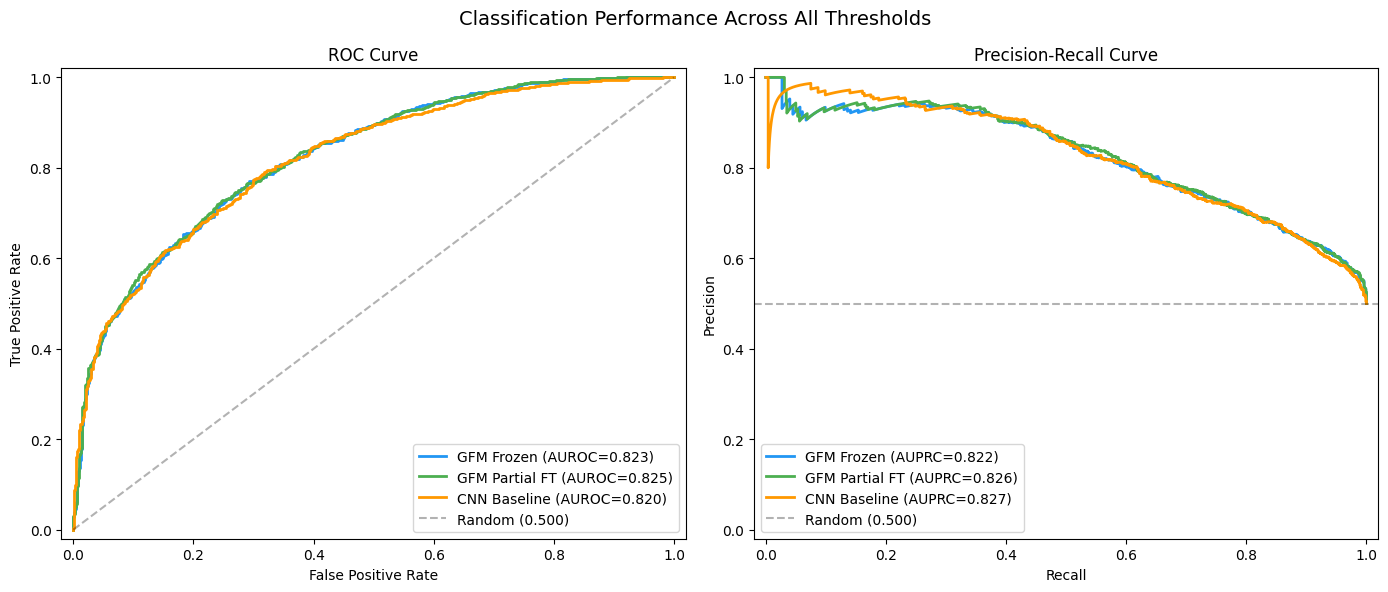

> The ROC curve shows discrimination ability (higher = better at separating classes)
> The PR curve is especially informative when positives are rare in deployment
> AUPRC baseline equals the class prevalence (here ~0.5 because of balanced design)


In [42]:
# ============================================================
# Step 8: ROC and Precision-Recall curves
# ============================================================
# These curves show performance ACROSS ALL thresholds, not just 0.5.
# This is more informative than any single-threshold metric.

# Reload frozen model for fair comparison
gfm_frozen = GFMClassifier(MODEL_NAME, freeze_backbone=True).to(device)
gfm_frozen.load_state_dict(torch.load('best_cls_frozen.pt', map_location=device, weights_only=True))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models_for_curves = [
    ('GFM Frozen',     gfm_frozen, test_loader_nt,  'gfm'),
    ('GFM Partial FT', gfm_model,  test_loader_nt,  'gfm'),
    ('CNN Baseline',   cnn_model,  test_loader_cnn, 'cnn'),
]
colors = ['#2196F3', '#4CAF50', '#FF9800']

for (name, mdl, ldr, mtype), color in zip(models_for_curves, colors):
    probs, labels = get_predictions(mdl, ldr, mtype)

    # ROC curve
    fpr, tpr, _ = roc_curve(labels, probs)
    auroc = roc_auc_score(labels, probs)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUROC={auroc:.3f})')

    # PR curve
    prec, rec, _ = precision_recall_curve(labels, probs)
    auprc = average_precision_score(labels, probs)
    axes[1].plot(rec, prec, color=color, lw=2, label=f'{name} (AUPRC={auprc:.3f})')

# ROC formatting
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (0.500)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')
axes[0].set_xlim(-0.02, 1.02)
axes[0].set_ylim(-0.02, 1.02)

# PR formatting
baseline_prev = test_df.label.mean()
axes[1].axhline(y=baseline_prev, color='k', linestyle='--', alpha=0.3,
                label=f'Random ({baseline_prev:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='lower left')
axes[1].set_xlim(-0.02, 1.02)
axes[1].set_ylim(-0.02, 1.02)

plt.suptitle('Classification Performance Across All Thresholds', fontsize=14)
plt.tight_layout()
plt.show()

print('> The ROC curve shows discrimination ability (higher = better at separating classes)')
print('> The PR curve is especially informative when positives are rare in deployment')
print('> AUPRC baseline equals the class prevalence (here ~0.5 because of balanced design)')


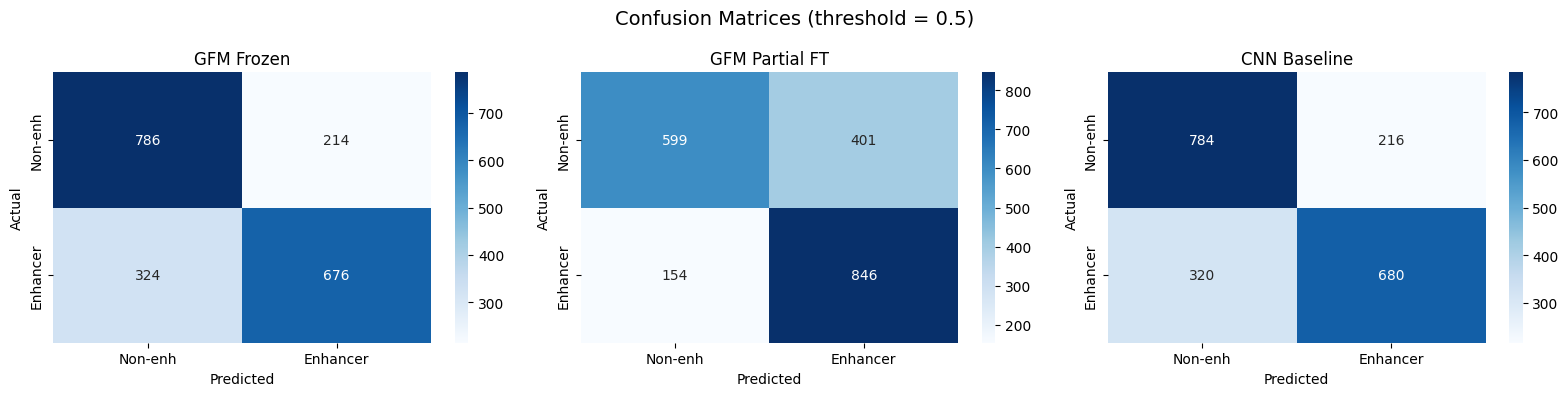

> Top-left (TN): correctly rejected non-enhancers
> Bottom-right (TP): correctly identified enhancers
> Top-right (FP): non-enhancers wrongly called enhancers (false alarms)
> Bottom-left (FN): enhancers missed by the model (missed detections)


In [43]:
# ============================================================
# Step 8: Confusion matrices
# ============================================================
# Where does each model make mistakes?

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, mdl, ldr, mtype) in zip(axes, models_for_curves):
    probs, labels = get_predictions(mdl, ldr, mtype)
    preds = (probs >= 0.5).astype(int)
    cm = confusion_matrix(labels, preds)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-enh', 'Enhancer'],
                yticklabels=['Non-enh', 'Enhancer'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(name)

plt.suptitle('Confusion Matrices (threshold = 0.5)', fontsize=14)
plt.tight_layout()
plt.show()

print('> Top-left (TN): correctly rejected non-enhancers')
print('> Bottom-right (TP): correctly identified enhancers')
print('> Top-right (FP): non-enhancers wrongly called enhancers (false alarms)')
print('> Bottom-left (FN): enhancers missed by the model (missed detections)')


Per-Chromosome AUROC (GFM Partial FT)
--------------------------------------------------
  chr19 (n=820): AUROC=0.857, F1=0.771
  chr20 (n=360): AUROC=0.807, F1=0.756
  chr21 (n=115): AUROC=0.760, F1=0.630
  chr22 (n=267): AUROC=0.791, F1=0.764
  chrX (n=438): AUROC=0.846, F1=0.730


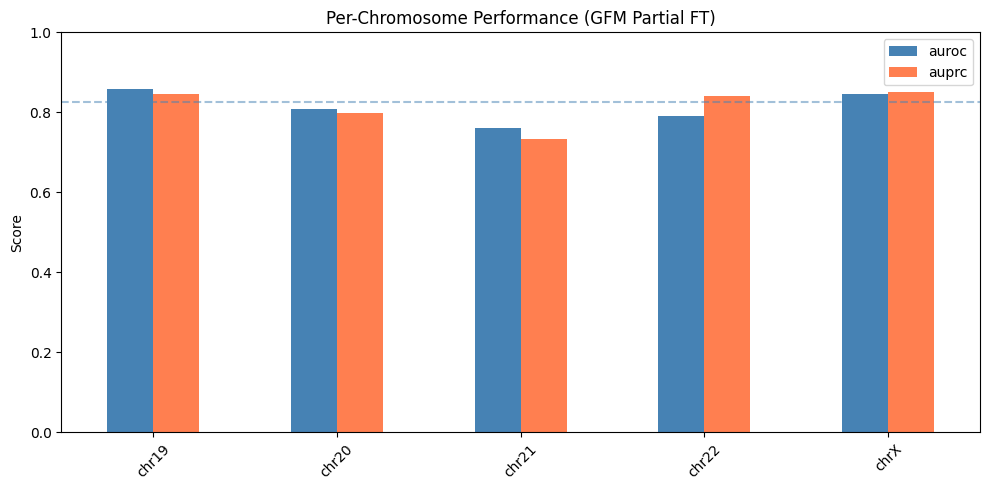

In [44]:
# ============================================================
# Step 8: Per-chromosome AUROC (using TRAINED model)
# ============================================================
# Lecture: "Report per-track, per-chromosome"
# IMPORTANT: uses the trained gfm_model, NOT a new one

print('Per-Chromosome AUROC (GFM Partial FT)')
print('-' * 50)

chrom_results = {}
for chrom in test_chroms:
    subset = test_df[test_df.chrom == chrom]
    if len(subset) < 20 or subset.label.nunique() < 2:
        print(f'  {chrom}: skipped (n={len(subset)}, need both classes)')
        continue

    ldr = DataLoader(NTClassificationDataset(subset), batch_size=BATCH_SIZE)
    metrics = evaluate(gfm_model, ldr, model_type='gfm')
    chrom_results[chrom] = metrics
    print(f'  {chrom} (n={len(subset):,}): AUROC={metrics["auroc"]:.3f}, F1={metrics["f1"]:.3f}')

if chrom_results:
    chrom_df = pd.DataFrame(chrom_results).T
    fig, ax = plt.subplots(figsize=(10, 5))
    chrom_df[['auroc', 'auprc']].plot.bar(ax=ax, color=['steelblue', 'coral'])
    ax.axhline(y=partial_test['auroc'], color='steelblue', linestyle='--', alpha=0.5)
    ax.set_ylabel('Score')
    ax.set_title('Per-Chromosome Performance (GFM Partial FT)')
    ax.set_ylim(0, 1)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()


### Saliency / Attribution Analysis

> *Lecture: "Do high-saliency regions overlap known enhancer motifs (e.g., AP-1, GATA)?"*

For classification, attribution tells us: **which positions made the model predict "enhancer"?**

We compare a correctly classified **enhancer** vs a correctly classified **non-enhancer**
to see what sequence features distinguish them.


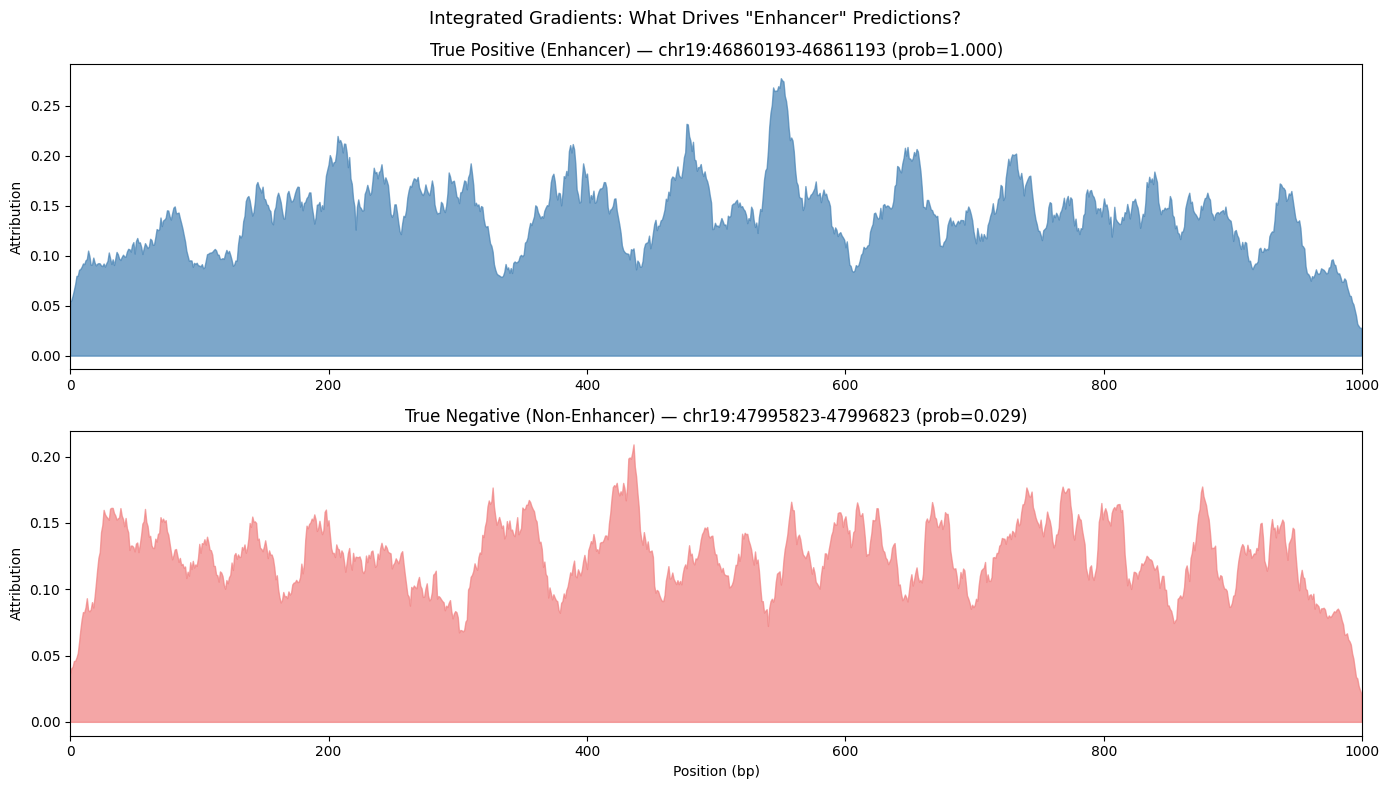

> Compare the two panels: enhancer regions should show concentrated,
> high-attribution peaks at motif locations (AP-1, GATA, ETS family).
> Non-enhancer regions should show more diffuse, lower attribution.


In [45]:
# ============================================================
# Step 8: Saliency analysis (Integrated Gradients on CNN)
# ============================================================

cnn_model.eval()

# Get predictions for test set to find correct classifications
probs_cnn, labels_cnn = get_predictions(cnn_model, test_loader_cnn, 'cnn')
preds_cnn = (probs_cnn >= 0.5).astype(int)

# Find a true positive (enhancer, correctly classified) and true negative
tp_mask = (labels_cnn == 1) & (preds_cnn == 1)
tn_mask = (labels_cnn == 0) & (preds_cnn == 0)

tp_indices = np.where(tp_mask)[0]
tn_indices = np.where(tn_mask)[0]

if len(tp_indices) == 0 or len(tn_indices) == 0:
    print('Not enough correct predictions for saliency analysis')
else:
    # Pick examples with highest confidence
    tp_idx = tp_indices[probs_cnn[tp_indices].argmax()]
    tn_idx = tn_indices[probs_cnn[tn_indices].argmin()]

    ig = IntegratedGradients(cnn_model)

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    for ax, idx, title, color in [
        (axes[0], tp_idx, 'True Positive (Enhancer)', 'steelblue'),
        (axes[1], tn_idx, 'True Negative (Non-Enhancer)', 'lightcoral'),
    ]:
        row = test_df.iloc[idx]
        encoded = torch.tensor(
            one_hot_encode(row.sequence), dtype=torch.float32
        ).unsqueeze(0).to(device)
        encoded.requires_grad_(True)

        attrs = ig.attribute(encoded, n_steps=50)
        importance = np.abs(attrs.squeeze().cpu().detach().numpy()).sum(axis=0)

        # Smooth with 20bp window
        smoothed = np.convolve(importance, np.ones(20)/20, mode='same')

        ax.fill_between(range(len(smoothed)), smoothed, alpha=0.7, color=color)
        pred_prob = probs_cnn[idx]
        ax.set_title(f'{title} — {row.chrom}:{row.win_start}-{row.win_end} '
                     f'(prob={pred_prob:.3f})')
        ax.set_ylabel('Attribution')
        ax.set_xlim(0, len(smoothed))

    axes[1].set_xlabel('Position (bp)')
    plt.suptitle('Integrated Gradients: What Drives "Enhancer" Predictions?', fontsize=13)
    plt.tight_layout()
    plt.show()

    print('> Compare the two panels: enhancer regions should show concentrated,')
    print('> high-attribution peaks at motif locations (AP-1, GATA, ETS family).')
    print('> Non-enhancer regions should show more diffuse, lower attribution.')


### Training Curves

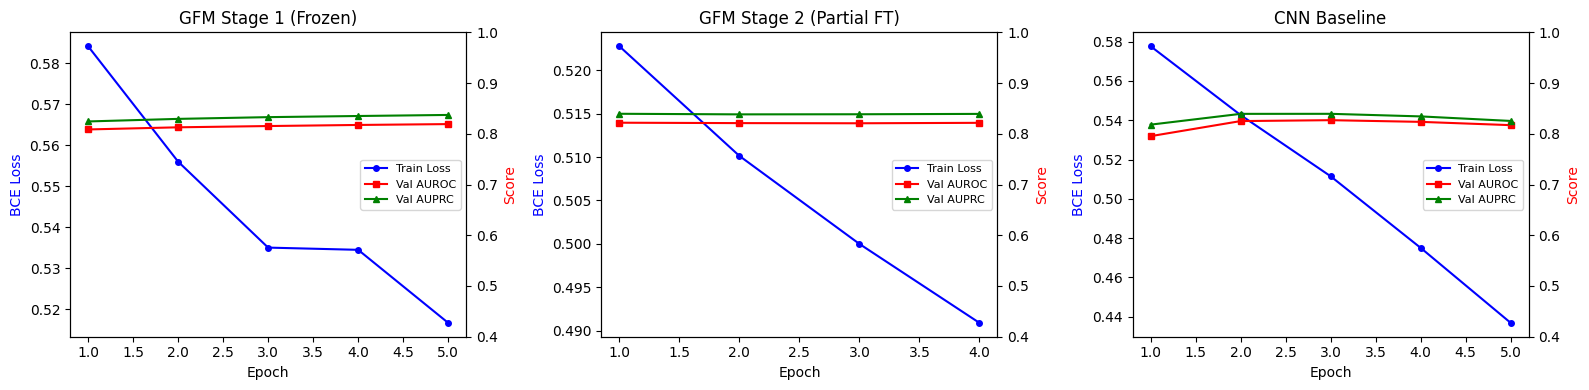

In [46]:
# ============================================================
# Training curves comparison
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (title, hist) in zip(axes, [
    ('GFM Stage 1 (Frozen)', history_s1),
    ('GFM Stage 2 (Partial FT)', history_s2),
    ('CNN Baseline', history_cnn),
]):
    epochs = range(1, len(hist['train_loss']) + 1)
    ax2 = ax.twinx()
    ax.plot(epochs, hist['train_loss'], 'b-o', markersize=4, label='Train Loss')
    ax2.plot(epochs, hist['val_auroc'], 'r-s', markersize=4, label='Val AUROC')
    ax2.plot(epochs, hist['val_auprc'], 'g-^', markersize=4, label='Val AUPRC')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE Loss', color='b')
    ax2.set_ylabel('Score', color='r')
    ax2.set_ylim(0.4, 1.0)
    ax.set_title(title)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=8)

plt.tight_layout()
plt.show()


## Regression vs Classification — A Comparison

Now that you've completed both notebooks, let's reflect on what changed and what didn't.

### Same pipeline, different questions

| Aspect | Regression Notebook | Classification Notebook |
|--------|:---:|:---:|
| **Question** | How active is this enhancer? | Is this an enhancer? |
| **Data** | Peaks only | Peaks + non-peak negatives |
| **Labels** | log(H3K27ac signal) | 0 or 1 |
| **Loss** | MSE | BCEWithLogitsLoss |
| **Metrics** | Pearson, Spearman | AUROC, AUPRC, F1 |
| **Key challenge** | Signal normalization | Negative example selection |
| **Models** | Same | Same (different output head) |
| **Splits** | Same | Same |
| **Fine-tuning** | Same staged approach | Same staged approach |

### Key insight

> The most impactful decisions were about **data and evaluation**, not about the model.
> This is the central message of the lecture: *"Most critical decisions happen
> outside the architecture."*

### When to use which?

- **Classification first:** to identify candidate enhancers genome-wide
- **Regression second:** to quantify and rank the candidates
- **In practice:** many studies do both — classify to find, regress to rank


## Summary

### What We Implemented

| Step | What's New vs Regression |
|:---:|---|
| 0 | Binary question: enhancer or not? |
| 3 | **Negative example generation** — the critical new step |
| 6 | **BCE loss + AUROC/AUPRC metrics** — appropriate for classification |
| 8 | **ROC/PR curves, confusion matrices** — classification-specific evaluation |

### Key Takeaways

1. **Negative selection is a modeling decision** — it determines what the classifier
   learns to distinguish. Random negatives ≠ GC-matched negatives ≠ promoter negatives.

2. **Metrics must match the task** — accuracy is misleading for imbalanced data;
   AUPRC is more informative when positives are rare.

3. **The same foundation model handles both tasks** — only the head and loss change.
   This is the power of pre-trained representations.

4. **Per-chromosome evaluation** catches overfitting that global metrics hide.

### Extensions

- **GC-matched negatives** — control for base composition bias
- **Hard negatives** (promoters, other regulatory elements) — force the model to learn
  enhancer-specific features rather than "regulatory vs background"
- **Cross-cell-type transfer** — train on K562, test on GM12878 or HepG2
- **Multi-label classification** — predict multiple histone marks simultaneously (DeepSEA-style)
- **Varying class ratios** — test with realistic 5% positive rate and measure AUPRC
